# Cross-Environment Generalization

This notebook loads `data/generalization.xlsx`, restricts attention to the train rows, computes CIP and AR, and produces the tables used in the numerical-results subsection.

---
### Helper functions
---


In [1]:
import importlib

import generalization_helpers

importlib.reload(generalization_helpers)

from generalization_helpers import (
    POLICIES,
    LEARNED_POLICIES,
    INSTANCE_COLUMNS,
    DIST_GROUP_MAP,
    DIST_GROUP_ORDER,
    DIST_GROUP_LABELS,
    ensure_generalization_workbook,
    summarize,
    build_overall_table,
    build_policy_performance_table,
    assign_quantile_groups,
    build_group_panel,
    make_legend_handles,
    format_axis,
    to_latex,
    boxplot_on_axis,
)

---
### Pre-processing step
---


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rc("text", usetex=True)
plt.rc("font", family="serif")

Path("plots").mkdir(exist_ok=True)

ensure_generalization_workbook("data/final results.xlsx", "data/generalization.xlsx")

PosixPath('data/generalization.xlsx')

In [3]:
path = "data/generalization.xlsx"
df = pd.read_excel(path, sheet_name="S5 merged")

# Keep only train rows and compute policy metrics used throughout the notebook.
df = df.loc[df["mode"].astype(str).str.lower().eq("train")].copy()

for policy in LEARNED_POLICIES:
    suffix = policy["suffix"]
    df[f"CIP_{suffix}"] = 100 * (1 - df[policy["cost_col"]] / df["avg_cost_basestock"])

df["CIP_BS"] = 0.0

rank_columns = [policy["cost_col"] for policy in POLICIES]
rank_df = df[rank_columns].rank(axis=1, method="average", ascending=True)
rank_df.columns = [f"AR_{policy['suffix']}" for policy in POLICIES]
df = pd.concat([df, rank_df], axis=1)

df["CV"] = df["demand_std"] / df["demand_mean"]
df["dist_group"] = df["distribution"].map(DIST_GROUP_MAP)

---
### Some Important Stats
---


In [4]:
print("Number of train rows:", len(df))
print(
    "Number of distinct train instances:",
    df[INSTANCE_COLUMNS].drop_duplicates().shape[0],
)
print("Demand families:", df["distribution"].nunique())

family_instance_counts = (
    df[INSTANCE_COLUMNS]
    .drop_duplicates()
    .groupby("distribution")
    .size()
    .div(df["lead_time"].nunique() * df["cost_ratio"].nunique())
    .astype(int)
    .reset_index(name="num_mu_sigma_specs")
    .sort_values(["num_mu_sigma_specs", "distribution"], ascending=[False, True])
)

demand_specs = df[["distribution", "demand_mean", "demand_std"]].drop_duplicates().copy()
print("\nNumber of unique demand specifications (family, mu, sigma):", len(demand_specs))

print("\nDistinct (mu, sigma) specifications by family:")
print(family_instance_counts.to_string(index=False))

Number of train rows: 10064
Number of distinct train instances: 10064
Demand families: 13

Number of unique demand specifications (family, mu, sigma): 629

Distinct (mu, sigma) specifications by family:
distribution  num_mu_sigma_specs
        zinb                 150
        beta                 123
         tri                  51
       binom                  48
       gamma                  36
      pareto                  36
        weib                  36
      normal                  33
        logn                  30
      negbin                  30
       dunif                  27
       cunif                  19
        geom                  10


In [5]:
demand_specs = df[["distribution", "demand_mean", "demand_std"]].drop_duplicates().copy()

for value_col, label, sort_cols in [
    ("demand_mean", "demand mean", ["distribution", "demand_std"]),
    ("demand_std", "demand std", ["distribution", "demand_mean"]),
]:
    min_value = demand_specs[value_col].min()
    max_value = demand_specs[value_col].max()

    print(f"Rows with minimum {label}:")
    print(
        demand_specs[demand_specs[value_col] == min_value]
        .sort_values(sort_cols)
        .to_string(index=False)
    )

    print(f"\nRows with maximum {label}:")
    print(
        demand_specs[demand_specs[value_col] == max_value]
        .sort_values(sort_cols)
        .to_string(index=False)
    )
    print()


Rows with minimum demand mean:
distribution  demand_mean  demand_std
        zinb        0.075    0.354436

Rows with maximum demand mean:
distribution  demand_mean  demand_std
       gamma       1600.0  357.770876

Rows with minimum demand std:
distribution  demand_mean  demand_std
      pareto          1.2    0.244949

Rows with maximum demand std:
distribution  demand_mean  demand_std
      pareto     2.000000         inf
      pareto     3.000000         inf
      pareto     4.333333         inf
      pareto    10.000000         inf
      pareto    15.000000         inf
      pareto    20.000000         inf
      pareto    21.666667         inf
      pareto    30.000000         inf
      pareto    40.000000         inf
      pareto    43.333333         inf
      pareto    60.000000         inf
      pareto    86.666667         inf
      pareto   100.000000         inf
      pareto   150.000000         inf
      pareto   200.000000         inf
      pareto   216.666667         inf
 

In [6]:
print("\nStats of coefficient of variation:")
print(df["CV"].describe())



Stats of coefficient of variation:
count    1.006400e+04
mean              inf
std               NaN
min      8.111071e-03
25%      3.068783e-01
50%      5.748728e-01
75%      1.069045e+00
max               inf
Name: CV, dtype: float64


/Users/parshan/miniconda3/envs/VSCode/lib/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


---
### Overall generalization performance
---


In [7]:
overall = build_overall_table(df)
overall

# print(to_latex(
#     overall,
#     index=False,
    #     caption="Overall performance on the train rows.",
#     label="tab:overall_generalization",
# ))


,Policy,Mean CIP (\%),Median CIP (\%),AR
0,pi_P,22.75,17.23,2.01
1,pi_E,21.95,16.28,2.20
2,pi_N,22.34,16.56,1.88
3,pi_BS,0.00,0.00,3.91


---
### Performance across lead times
---


In [8]:
lead_tbl = summarize(["lead_time"]).rename(columns={"lead_time": "L"})
lead_tbl

# print(to_latex(
#     lead_tbl,
#     index=False,
    #     caption="Performance across lead times on the train rows.",
#     label="tab:lead_generalization",
# ))


,L,P_CIP,E_CIP,N_CIP,BS_CIP,P_AR,E_AR,N_AR,BS_AR,n
0,2,9.37,7.67,8.00,0.0,1.81,2.25,2.06,3.89,2516
1,4,18.97,18.01,18.53,0.0,1.94,2.27,1.87,3.91,2516
2,6,27.58,27.22,27.60,0.0,2.10,2.16,1.81,3.92,2516
3,8,35.08,34.92,35.23,0.0,2.17,2.12,1.78,3.92,2516


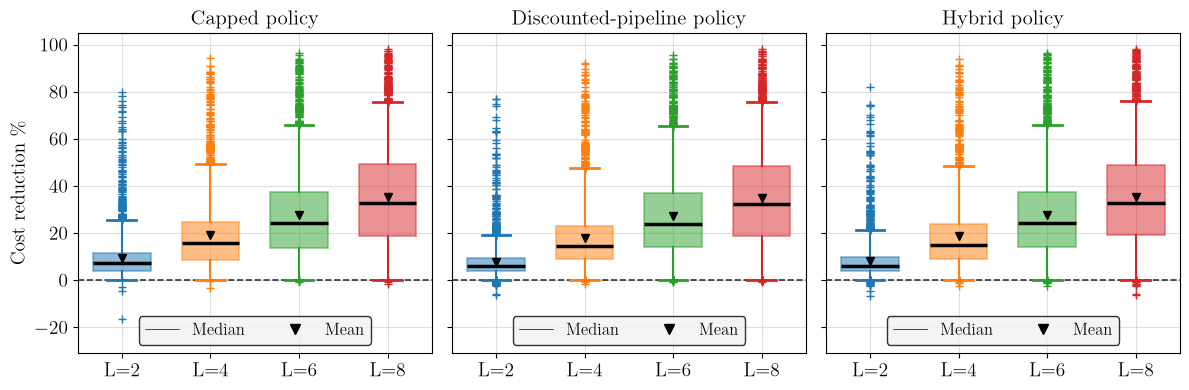

In [9]:
lead_times = sorted(df["lead_time"].dropna().unique())
lead_labels = [f"L={int(lead_time)}" for lead_time in lead_times]
lead_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"][: len(lead_times)]
legend_handles = make_legend_handles(median_lw=0.5)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, policy in zip(axes, LEARNED_POLICIES):
    panel = build_group_panel(df, "lead_time", lead_times, f"CIP_{policy['suffix']}", labels=lead_labels)
    boxplot_on_axis(
        ax=ax,
        data=panel,
        cols=panel.columns.tolist(),
        box_colors=lead_colors,
        labels=lead_labels,
        title=policy["title"],
        ylabel=r"Cost reduction  $\%$" if ax is axes[0] else None,
        refline=0,
        vert=True,
        showfliers=True,
    )
    ax.set_ylim([-31, 105])
    format_axis(ax, tick_size=14, label_size=14, title_size=15)
    ax.legend(
        handles=legend_handles,
        loc="lower center",
        facecolor="#f2f2f2",
        frameon=True,
        fancybox=True,
        edgecolor="black",
        fontsize=12,
        ncol=3
    )

fig.tight_layout()
fig.savefig("plots/leadtime_comparison.pdf", bbox_inches="tight")
plt.show()


In [10]:
lead_perf_tbl = build_policy_performance_table(df, "lead_time", "L")
lead_perf_tbl

# print(
#     lead_perf_tbl.to_latex(
#         index=False,
#         caption="Mean CIP and AR across lead times.",
#         label="tab:leadtime_cip_ar",
#         escape=False,
#     )
# )


,L,Capped_CIP,Capped_AR,DiscountedPipeline_CIP,DiscountedPipeline_AR,Hybrid_CIP,Hybrid_AR,BaseStock_AR,n
0,2,9.37,1.81,7.67,2.25,8.00,2.06,3.89,2516
1,4,18.97,1.94,18.01,2.27,18.53,1.87,3.91,2516
2,6,27.58,2.10,27.22,2.16,27.60,1.81,3.92,2516
3,8,35.08,2.17,34.92,2.12,35.23,1.78,3.92,2516


---
### Performance across cost ratios
---


In [11]:
cost_tbl = summarize(["cost_ratio"]).rename(columns={"cost_ratio": "R"})
cost_tbl

# print(to_latex(
#     cost_tbl,
#     index=False,
    #     caption="Performance across cost ratios on the train rows.",
#     label="tab:cost_generalization",
# ))


,R,P_CIP,E_CIP,N_CIP,BS_CIP,P_AR,E_AR,N_AR,BS_AR,n
0,2,27.14,27.04,27.23,0.0,2.31,2.13,1.72,3.84,2516
1,4,23.49,23.01,23.32,0.0,2.06,2.17,1.86,3.91,2516
2,6,21.43,20.47,20.91,0.0,1.90,2.24,1.93,3.93,2516
3,10,18.94,17.29,17.89,0.0,1.76,2.26,2.01,3.96,2516


---
### Performance across demand distributions
---


In [12]:
dist_tbl = summarize(["distribution"]).sort_values("distribution").reset_index(drop=True)
dist_tbl

# print(to_latex(
#     dist_tbl,
#     index=False,
    #     caption="Performance across demand distributions on the train rows.",
#     label="tab:dist_generalization",
# ))


,distribution,P_CIP,E_CIP,N_CIP,BS_CIP,P_AR,E_AR,N_AR,BS_AR,n
0,beta,27.35,25.56,26.16,0.0,1.85,2.27,1.88,3.99,1968
1,binom,50.98,49.09,50.77,0.0,1.90,2.29,1.81,4.00,768
2,cunif,23.24,22.49,22.72,0.0,1.61,2.42,1.97,4.00,304
3,dunif,23.06,22.19,22.48,0.0,1.58,2.47,1.95,4.00,432
4,gamma,21.55,21.27,21.58,0.0,2.15,2.16,1.69,4.00,576
5,geom,9.11,9.72,9.81,0.0,2.81,1.69,1.66,3.84,160
6,logn,17.05,17.16,17.27,0.0,2.49,1.94,1.56,4.00,480
7,negbin,24.55,23.98,24.32,0.0,1.96,2.24,1.81,3.99,480
8,normal,39.38,37.46,38.18,0.0,1.47,2.61,1.92,4.00,528
9,pareto,22.81,22.80,22.84,0.0,2.33,2.01,1.66,4.00,576


# Light- to moderate-tailed

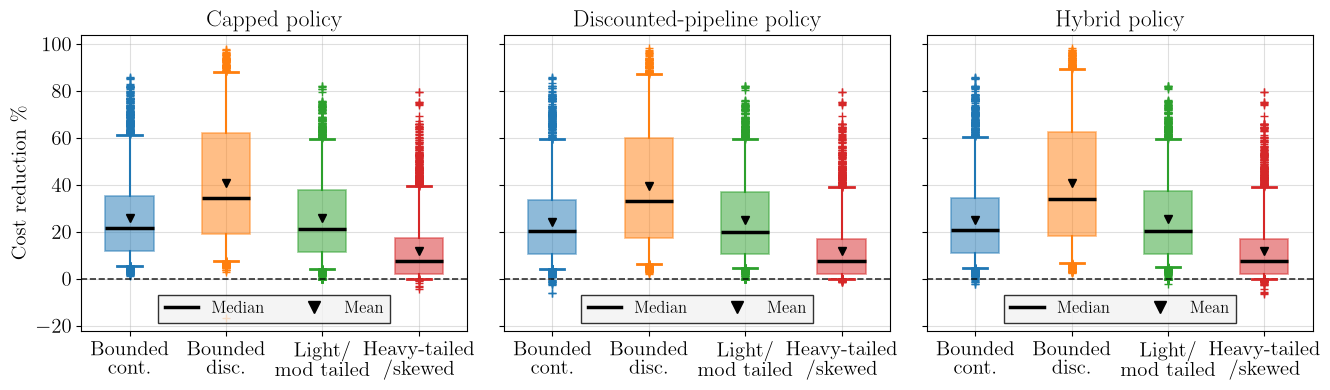

In [24]:
group_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
legend_handles = make_legend_handles(mean_size=8, outlier_size=9)
dist_group_plot_labels = [
    "Bounded\ncont.",
    "Bounded\ndisc.",
    "Light/\nmod tailed",
    "Heavy-tailed\n/skewed",
]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4), sharey=True)

for ax, policy in zip(axes, LEARNED_POLICIES):
    panel = build_group_panel(
        df,
        "dist_group",
        DIST_GROUP_ORDER,
        f"CIP_{policy['suffix']}",
        labels=dist_group_plot_labels,
    )
    boxplot_on_axis(
        ax=ax,
        data=panel,
        cols=panel.columns.tolist(),
        box_colors=group_colors,
        labels=dist_group_plot_labels,
        title=policy["title"],
        ylabel=r"Cost reduction $\%$" if ax is axes[0] else None,
        refline=0,
        vert=True,
        showfliers=True,
        box_width=0.5,
    )
    format_axis(ax, tick_size=15, label_size=15, title_size=17, rotation=0)
    ax.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=2,
        frameon=True,
        fancybox=False,
        edgecolor="black",
        facecolor="#f2f2f2",
        fontsize=12,
    )

fig.tight_layout()
fig.savefig("plots/dist_comparison.pdf", bbox_inches="tight")
plt.show()

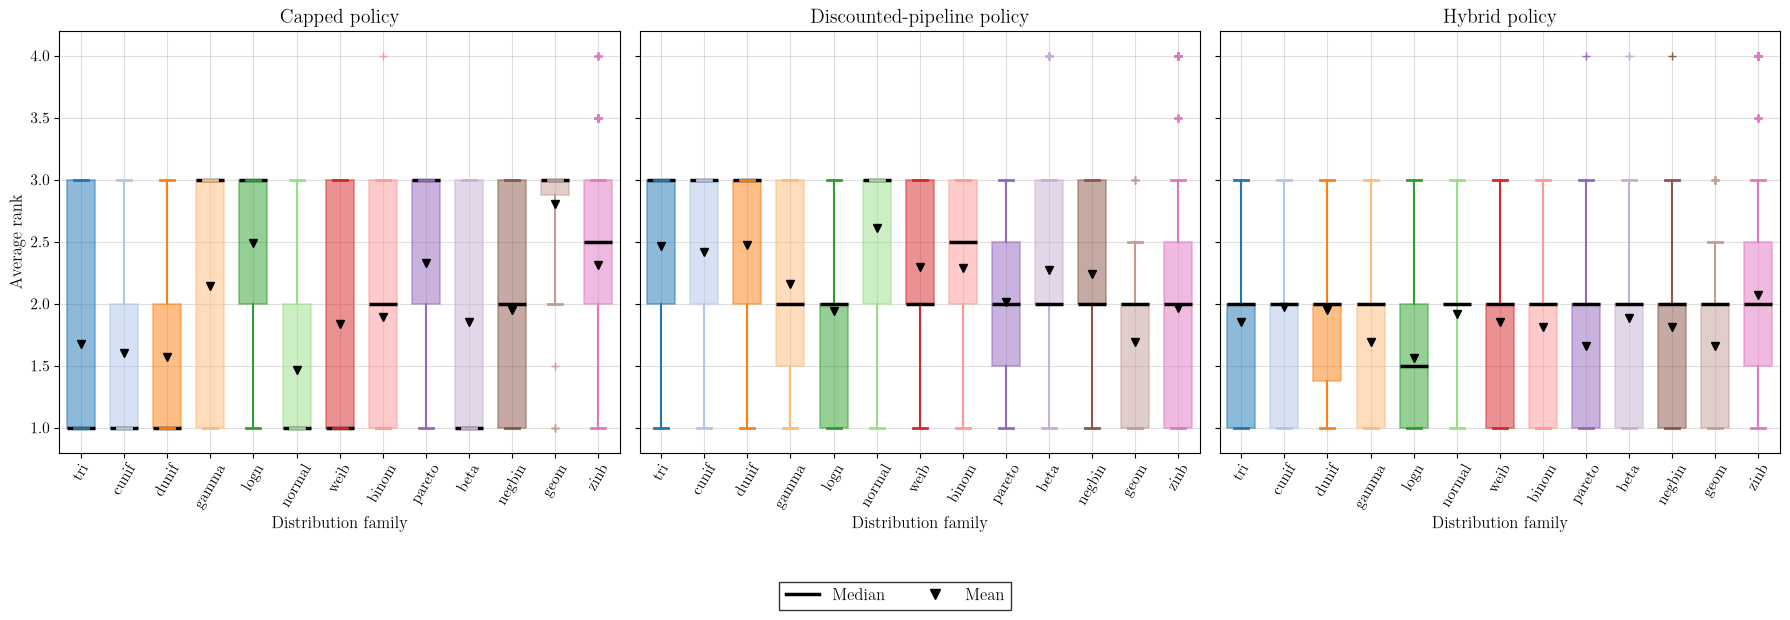

In [14]:
dist_order = (
    df.groupby("distribution")[["AR_P", "AR_E", "AR_N"]]
    .mean()
    .mean(axis=1)
    .sort_values(ascending=True)
    .index
    .tolist()
)

cmap = plt.get_cmap("tab20")
dist_colors = [cmap(i % 20) for i in range(len(dist_order))]
legend_handles = make_legend_handles(mean_size=7, outlier_size=8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, policy in zip(axes, LEARNED_POLICIES):
    panel = build_group_panel(df, "distribution", dist_order, f"AR_{policy['suffix']}")
    boxplot_on_axis(
        ax=ax,
        data=panel,
        cols=panel.columns.tolist(),
        box_colors=dist_colors,
        labels=dist_order,
        title=policy["title"],
        xlabel="Distribution family",
        ylabel="Average rank" if ax is axes[0] else None,
        refline=None,
        vert=True,
        showfliers=True,
    )
    format_axis(ax, tick_size=11 if ax is not axes[0] else 11, label_size=12, title_size=14, rotation=60)
    ax.set_ylim(0.8, 4.2)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    bbox_to_anchor=(0.5, -0.04),
    fontsize=12,
)

fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


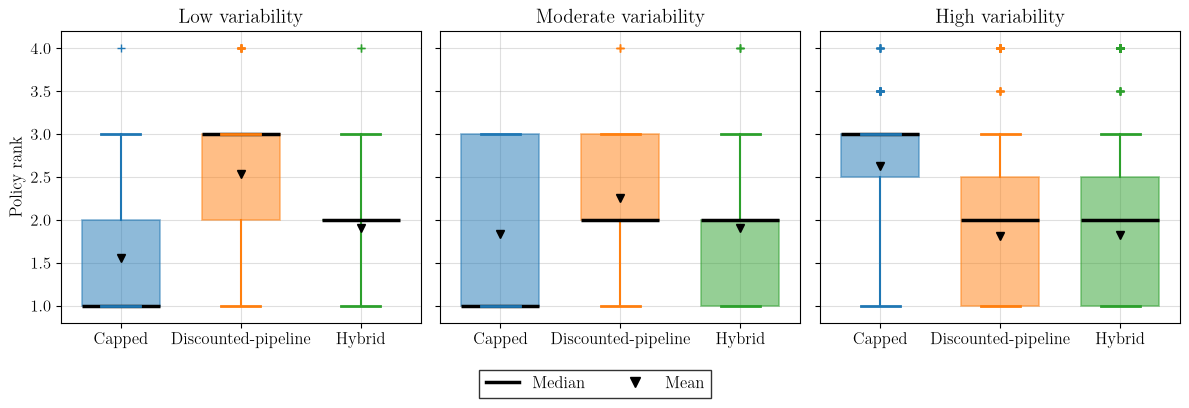

In [15]:
cv_labels = ["Low variability", "Moderate variability", "High variability"]
assign_quantile_groups(df, "CV", [1 / 3, 2 / 3], cv_labels, "cv_group_tercile")

policy_colors = ["tab:blue", "tab:orange", "tab:green"]
policy_labels = [policy["label"] for policy in LEARNED_POLICIES]
legend_handles = make_legend_handles(mean_size=7, outlier_size=8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, cv_label in zip(axes, cv_labels):
    subset = df[df["cv_group_tercile"] == cv_label]
    panel = pd.DataFrame(
        {
            policy["label"]: subset[f"AR_{policy['suffix']}"] .reset_index(drop=True)
            for policy in LEARNED_POLICIES
        }
    )
    boxplot_on_axis(
        ax=ax,
        data=panel,
        cols=panel.columns.tolist(),
        box_colors=policy_colors,
        labels=policy_labels,
        title=cv_label,
        ylabel="Policy rank" if ax is axes[0] else None,
        refline=None,
        vert=True,
        showfliers=True,
    )
    format_axis(ax, tick_size=12, label_size=12, title_size=14)
    ax.set_ylim(0.8, 4.2)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    bbox_to_anchor=(0.5, -0.03),
    fontsize=12,
)

fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


### Policy Rank

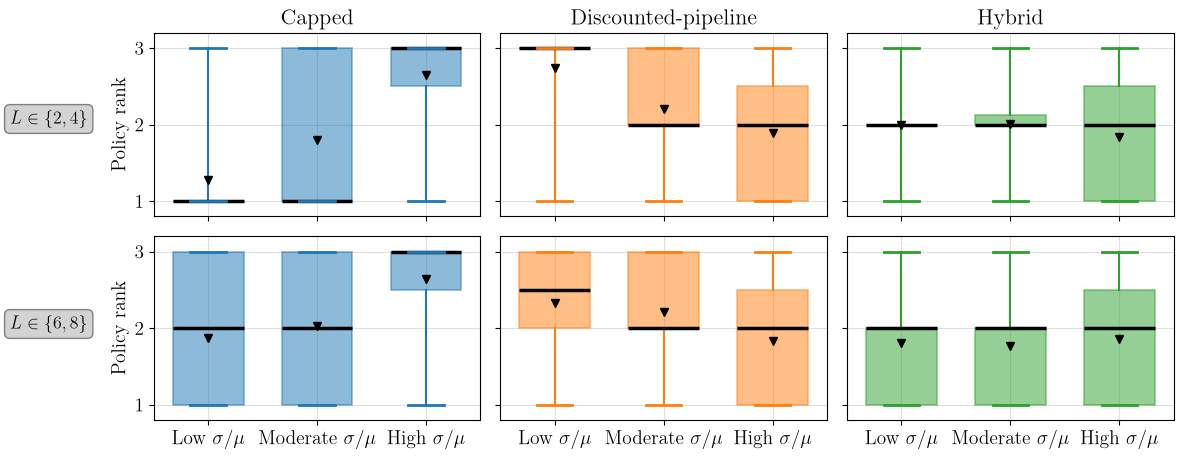

In [38]:
cv_labels = [r"Low $\sigma/\mu$", r"Moderate $\sigma/\mu$", r"High $\sigma/\mu$"]
assign_quantile_groups(df, "CV", [0.25, 0.75], cv_labels, "cv_group_quartile")

df["lead_time_bucket"] = pd.cut(
    df["lead_time"],
    bins=[1.5, 4.0, 8.0],
    labels=[r"$L \in \{2,4\}$", r"$L \in \{6,8\}$"],
    ordered=True,
)

lead_time_bucket_labels = [r"$L \in \{2,4\}$", r"$L \in \{6,8\}$"]
policy_colors = ["tab:blue", "tab:orange", "tab:green"]
policy_labels = [policy["label"] for policy in LEARNED_POLICIES]

fig, axes = plt.subplots(
    len(lead_time_bucket_labels),
    len(policy_labels),
    figsize=(12, 5),
    sharex=True,
    sharey=True,
)

for row_idx, lead_bucket in enumerate(lead_time_bucket_labels):
    for col_idx, policy in enumerate(LEARNED_POLICIES):
        ax = axes[row_idx, col_idx]
        subset = df[df["lead_time_bucket"] == lead_bucket]
        panel = pd.DataFrame(
            {
                cv_label: subset.loc[
                    subset["cv_group_quartile"] == cv_label,
                    f"AR_{policy['suffix']}",
                ].reset_index(drop=True)
                for cv_label in cv_labels
            }
        )
        boxplot_on_axis(
            ax=ax,
            data=panel,
            cols=panel.columns.tolist(),
            box_colors=[policy_colors[col_idx]] * len(cv_labels),
            labels=cv_labels,
            title=policy_labels[col_idx] if row_idx == 0 else None,
            ylabel="Policy rank" if col_idx == 0 else None,
            refline=None,
            vert=True,
            showfliers=True,
        )
        format_axis(ax, tick_size=14, label_size=14, title_size=16)
        ax.set_ylim(0.8, 3.2)
        ax.set_yticks([1, 2, 3])
        ax.set_yticklabels([1, 2, 3])

fig.text(
    0.05,
    0.75,
    r"$L \in \{2,4\}$",
    rotation=0,
    va="center",
    ha="center",
    fontsize=13,
    bbox=dict(facecolor="lightgray", edgecolor="gray", boxstyle="round,pad=0.3"),
)
fig.text(
    0.05,
    0.34,
    r"$L \in \{6,8\}$",
    rotation=0,
    va="center",
    ha="center",
    fontsize=13,
    bbox=dict(facecolor="lightgray", edgecolor="gray", boxstyle="round,pad=0.3"),
)

fig.tight_layout(rect=[0.09, 0.06, 1, 1])
fig.savefig("plots/AR_by_Lbucket_and_CV.pdf", bbox_inches="tight")
plt.show()
